# Week 13-14: ANN and DL Comparison

This notebook trains a simple ANN from scratch with MiniLearn and compares it with an off-the-shelf neural network from scikit-learn.

## Section 1. Environment and Data

Set up the project path, load the feature table, and prepare the train/test split.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

from minilearn.classifiers import SimpleANNClassifier

In [2]:
feature_path = PROJECT_ROOT / 'data' / 'features.csv'
df = pd.read_csv(feature_path)

target_col = 'emotion_code' if 'emotion_code' in df.columns else 'emotion'
drop_cols = [
    column_name for column_name in [
        'filepath', 'filename', 'emotion', 'emotion_code', 'vocal_channel',
        'modality', 'intensity', 'statement', 'actor_id', 'repetition'
    ] if column_name in df.columns
]

X = df.drop(columns=drop_cols)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Section 2. Train the Models

Fit the MiniLearn ANN and the sklearn MLP on the same standardized features.

In [3]:
ann = SimpleANNClassifier(hidden_layer_sizes=(64, 32), learning_rate=0.01, max_epochs=50, batch_size=32, random_state=42)
ann.fit(X_train_scaled, y_train.to_numpy())
ann_pred = ann.predict(X_test_scaled)

sk_mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=200, random_state=42)
sk_mlp.fit(X_train_scaled, y_train)
sk_pred = sk_mlp.predict(X_test_scaled)

results = pd.DataFrame([
    {
        'model': 'MiniLearn SimpleANN',
        'accuracy': accuracy_score(y_test, ann_pred),
        'macro_f1': f1_score(y_test, ann_pred, average='macro'),
    },
    {
        'model': 'sklearn MLPClassifier',
        'accuracy': accuracy_score(y_test, sk_pred),
        'macro_f1': f1_score(y_test, sk_pred, average='macro'),
    },
])
results

,model,accuracy,macro_f1
0,MiniLearn SimpleANN,0.645833,0.632852
1,sklearn MLPClassifier,0.725694,0.715666


## Section 3. Evaluation

Compare accuracy, macro F1, and confusion matrices for both neural network models.

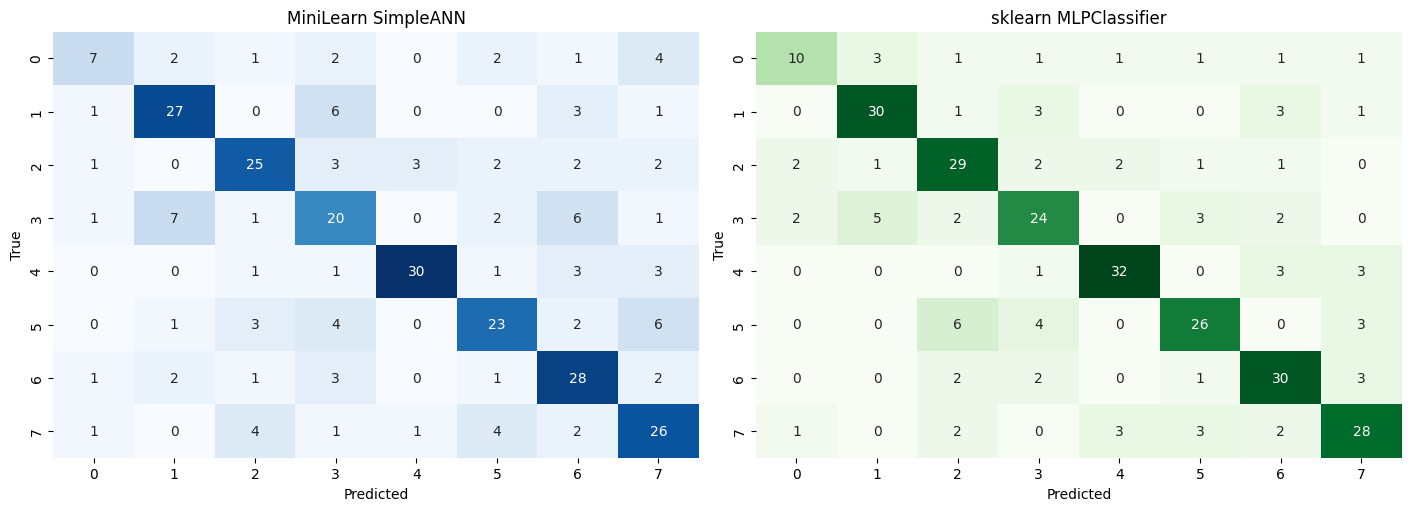

MiniLearn ANN accuracy: 0.6458333333333334
MiniLearn ANN macro F1: 0.63285229641511
sklearn MLP accuracy: 0.7256944444444444
sklearn MLP macro F1: 0.7156657134843409


In [4]:
labels = np.unique(y)
cm_ann = confusion_matrix(y_test, ann_pred, labels=labels)
cm_sk = confusion_matrix(y_test, sk_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('MiniLearn SimpleANN')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('sklearn MLPClassifier')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.show()

print('MiniLearn ANN accuracy:', accuracy_score(y_test, ann_pred))
print('MiniLearn ANN macro F1:', f1_score(y_test, ann_pred, average='macro'))
print('sklearn MLP accuracy:', accuracy_score(y_test, sk_pred))
print('sklearn MLP macro F1:', f1_score(y_test, sk_pred, average='macro'))

## Conclusion

The MiniLearn ANN provides a working from-scratch neural network baseline. Its performance can now be compared directly with sklearn's MLP on the same standardized SER features, which makes it easier to judge whether the custom implementation is competitive or still needs tuning. In the finished report, this section should summarize the final scores, identify the emotions that are still hardest to classify, and explain how the ANN compares with the classical models from earlier weeks.